Threshold : 12.0015054797889

Distribution des classes :
0    731
1    725
Name: count, dtype: int64

========== COEFFICIENTS ==========
Intercept :
[-3.48663102e-05]

Coefficients :
[[-3.05328077e-03 -3.19727068e-03  7.59388833e-05  2.34620509e-01
   1.10227910e-01  8.38055439e-02  1.01930102e-02  2.57869370e-04
   1.50447183e-04 -2.02588125e-04 -6.82214347e-05 -1.20362377e-04
   5.82949651e-04  1.71187878e-03 -3.51120746e-04  1.94370768e-03
   5.55128915e-03  6.39511835e-03  2.02221159e-02  7.79524843e-03
  -9.49828255e-02 -5.67475609e-02 -6.81066399e-02  1.28555148e-01
  -4.59075052e-02  4.12558457e-02  2.25921758e-03  4.32094097e-03
   6.38801493e-03  4.91139799e-03  1.50581537e-02  6.90285292e-03
   1.77088508e-02 -4.33037024e-04  7.01074288e-03 -5.33504789e-02
   1.82334530e-03 -3.95383443e-03  1.26687816e-02 -5.14031200e-03
   3.72890340e-02 -4.08983648e-02 -1.62275849e-04  1.27580256e-04
   2.53859534e-02  4.11614739e-03  8.22309427e-04 -3.03591058e-02
   8.47762560e-03  1.4419

C:\Users\Acer\projet1\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


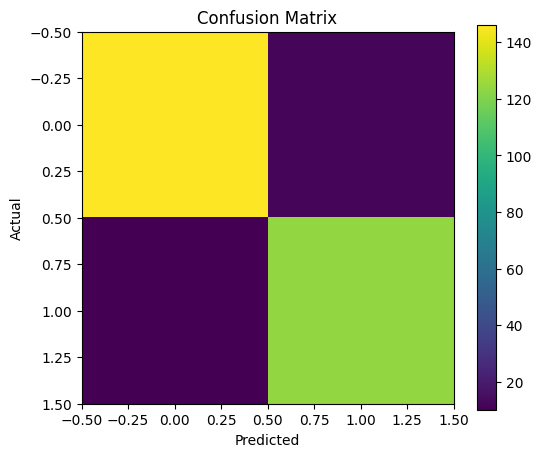


========== PERFORMANCE ==========
Accuracy : 0.9246575342465754
Precision : 0.9117647058823529
Recall : 0.9253731343283582
F1 Score : 0.9185185185185185

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       158
           1       0.91      0.93      0.92       134

    accuracy                           0.92       292
   macro avg       0.92      0.92      0.92       292
weighted avg       0.92      0.92      0.92       292



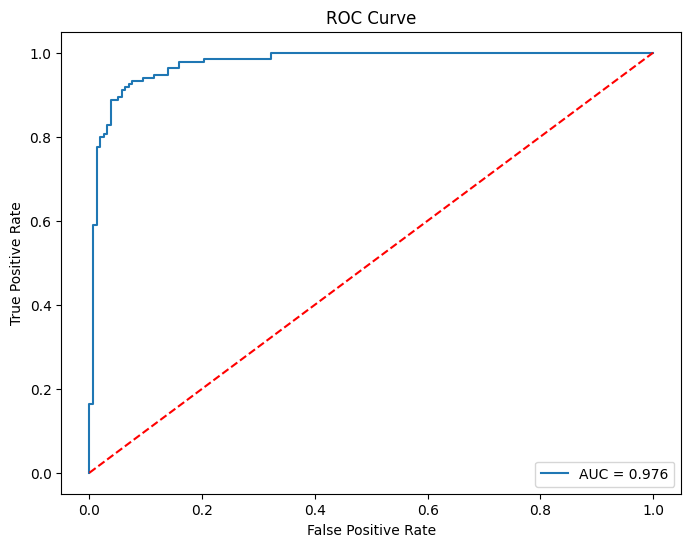


AUC Score : 0.9762422066880787

========== INTERPRETATION ==========

- Si OR > 1 :
  la variable augmente la probabilité
  d’appartenir à la classe 1.

- Si OR < 1 :
  la variable réduit la probabilité.

- Accuracy :
  proportion des prédictions correctes.

- Recall :
  capacité à détecter correctement
  les cas positifs.

- Precision :
  qualité des prédictions positives.

- F1 Score :
  compromis entre précision et rappel.

- AUC proche de 1 :
  excellent modèle.

- La courbe ROC permet d’évaluer
  la capacité de discrimination du modèle.



In [1]:
# ============================================================
# IMPORTATION DES LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)


# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================

X = pd.read_csv(
    r"C:/Users/Acer/Desktop/House Pricing R/data/Cleaned/X_encoded.csv"
)

y = pd.read_csv(
    r"C:/Users/Acer/Desktop/House Pricing R/data/Cleaned/y.csv"
).values.ravel()


# ============================================================
# TRANSFORMATION DE Y EN VARIABLE BINAIRE
# (0 = prix faible / 1 = prix élevé)
# ============================================================

threshold = np.median(y)

y_binary = (y > threshold).astype(int)

print("Threshold :", threshold)

print("\nDistribution des classes :")
print(pd.Series(y_binary).value_counts())


# ============================================================
# DIVISION TRAIN / TEST
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42
)


# ============================================================
# MODÈLE DE RÉGRESSION LOGISTIQUE
# ============================================================

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(X_train, y_train)


# ============================================================
# PRÉDICTIONS
# ============================================================

y_pred = log_model.predict(X_val)

y_prob = log_model.predict_proba(X_val)[:,1]


# ============================================================
# COEFFICIENTS DU MODÈLE
# ============================================================

print("\n========== COEFFICIENTS ==========")

print("Intercept :")
print(log_model.intercept_)

print("\nCoefficients :")
print(log_model.coef_)


# ============================================================
# ODDS RATIO
# ============================================================

odds_ratios = np.exp(log_model.coef_[0])

or_df = pd.DataFrame({
    "Variable": X.columns,
    "Odds Ratio": odds_ratios
})

print("\n========== ODDS RATIOS ==========")

print(or_df.sort_values(
    by="Odds Ratio",
    ascending=False
).head(15))


# ============================================================
# MATRICE DE CONFUSION
# ============================================================

cm = confusion_matrix(y_val, y_pred)

print("\n========== CONFUSION MATRIX ==========")

print(cm)


# ============================================================
# AFFICHAGE MATRICE DE CONFUSION
# ============================================================

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# ============================================================
# MÉTRIQUES DE PERFORMANCE
# ============================================================

accuracy = accuracy_score(y_val, y_pred)

precision = precision_score(y_val, y_pred)

recall = recall_score(y_val, y_pred)

f1 = f1_score(y_val, y_pred)

print("\n========== PERFORMANCE ==========")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)


# ============================================================
# RAPPORT DE CLASSIFICATION
# ============================================================

print("\n========== CLASSIFICATION REPORT ==========")

print(classification_report(y_val, y_pred))


# ============================================================
# COURBE ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_val,
    y_prob
)

auc_score = roc_auc_score(
    y_val,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    'r--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


# ============================================================
# AUC
# ============================================================

print("\nAUC Score :", auc_score)


# ============================================================
# INTERPRÉTATION DES ODDS RATIOS
# ============================================================

print("\n========== INTERPRETATION ==========")

print("""
- Si OR > 1 :
  la variable augmente la probabilité
  d’appartenir à la classe 1.

- Si OR < 1 :
  la variable réduit la probabilité.

- Accuracy :
  proportion des prédictions correctes.

- Recall :
  capacité à détecter correctement
  les cas positifs.

- Precision :
  qualité des prédictions positives.

- F1 Score :
  compromis entre précision et rappel.

- AUC proche de 1 :
  excellent modèle.

- La courbe ROC permet d’évaluer
  la capacité de discrimination du modèle.
""")